In [16]:
import ctypes
import numpy as np
import numpy.ctypeslib
import random


rust_path = "../mylibrary/target/debug/deps/libmylibrary.so"

my_lib = ctypes.cdll.LoadLibrary(rust_path)

my_lib.create_linear_regression.argtypes = [ctypes.c_double, ctypes.c_double]
my_lib.create_linear_regression.restype = ctypes.c_void_p

my_lib.predict_linear_regression.argtypes = [ctypes.c_void_p, ctypes.POINTER(ctypes.c_double), ctypes.c_int32]
my_lib.predict_linear_regression.restype = ctypes.POINTER(ctypes.c_double)

my_lib.fit_linear_regression.argtypes = [ctypes.c_void_p, ctypes.POINTER(ctypes.c_double), ctypes.POINTER(ctypes.c_double), ctypes.c_int, ctypes.c_int, ctypes.c_double]
my_lib.fit_linear_regression.restype = ctypes.c_void_p
 
my_lib.history_get_losses.argtypes = [ctypes.c_void_p]
my_lib.history_get_losses.restype = ctypes.POINTER(ctypes.c_double)



train_x = np.array([x for x in range(100)], np.float64)
# train_y = np.array([(celsius * 9/5) + 32 for celsius in train_x], np.float64)
train_y = np.array([30*x + 15 for x in train_x], np.float64)



c_X = np.ctypeslib.as_ctypes(train_x)
c_y = np.ctypeslib.as_ctypes(train_y)

model = my_lib.create_linear_regression(5,4)

epochs = 10000

history = my_lib.fit_linear_regression(model, c_X, c_y, len(c_X), epochs, 0.00000001)

data = np.array([1,2,3,4,5], dtype=np.float64)

c_data = np.ctypeslib.as_ctypes(data)
p_pred = my_lib.predict_linear_regression(model, c_data, len(data))

pred = numpy.ctypeslib.as_array(p_pred, (len(data),))
print(pred)

p_losses = my_lib.history_get_losses(history)
losses = np.ctypeslib.as_array(p_losses,(epochs,))

print("COMPILE")

[ 34.56595661  64.72567388  94.88539116 125.04510843 155.20482571]
COMPILE


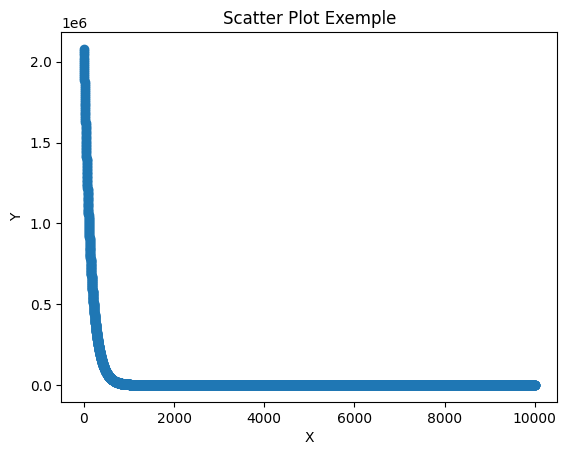

In [2]:
import matplotlib.pyplot as plt

# Données pour l'exemple
x = [i for i in range(0,epochs)]
y = losses

# Créer un scatter plot
plt.scatter(x, y)

# Ajouter des titres et des labels
plt.title('Scatter Plot Exemple')

plt.xlabel('X')
plt.ylabel('Y')

# Afficher le plot
plt.show()


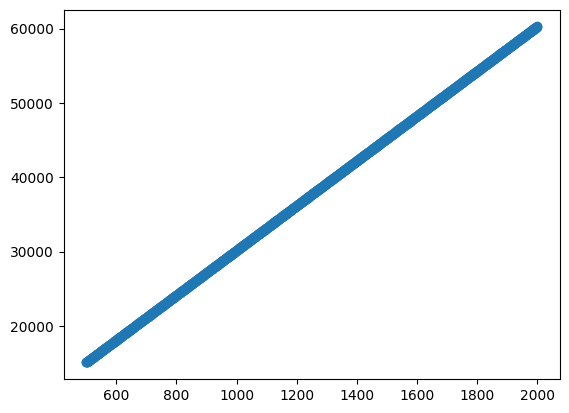

In [13]:
test_x = np.array([x for x in range(500,2000)], dtype=np.float64)
test_y = np.array([30*x + 15 for x in test_x], dtype=np.float64)

c_test_x = np.ctypeslib.as_ctypes(test_x)
p_pred = my_lib.predict_linear_regression(model, c_test_x, len(test_x))
pred = np.ctypeslib.as_array(p_pred, (len(test_x),))

plt.scatter(test_x,pred)